# GSD2T Asset Management — Quant Fund Pitch
### ESADE Asset Management · Group Project · Live pitch 10 June 2026

This notebook walks through everything we built: the universe, the pitched strategy,
the six research iterations behind it, and the full backtest-hygiene checks
(factor regression, deflated Sharpe, parameter sensitivity, stress tests).

> **All performance is SIMULATED on historical data. The fund "GSD2T" does not exist.**
> Figures are loaded from the result files produced by our backtest scripts
> (`strategy_one_full.py`, `strategies_tech.py`, `strategy_two_variants.py`).

## 0 · Setup — load the result files

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({"figure.figsize": (11, 5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})

ROOT = Path.cwd()
GSD2T = json.load(open(ROOT / "gsd2t_full.json"))                  # S1 — the pitched fund
FULL  = json.load(open(ROOT / "strategies_full_comparison.json"))  # all six iterations
TECH  = json.load(open(ROOT / "tech_comparison_data.json"))        # S1/S2/S3 three-way
S2    = json.load(open(ROOT / "s2_variants_full.json"))            # S2 fix experiments

m = GSD2T["meta"]
print("Fund:    ", m["fund_name"])
print("Strategy:", m["strategy"])
print("Universe:", m["universe"])
print("Window:  ", m["window"])
print("Costs:   ", m["tc_bps"], "bps round-trip")

Fund:     GSD2T Asset Management
Strategy: Macro-Overlay Tech
Universe: S&P 500 ∩ GICS Information Technology (73 stocks)
Window:   2002-01 to 2026-05
Costs:    15 bps round-trip


In [2]:
# Formatting helpers used throughout
def as_pct(x):   return f"{x*100:,.1f}%"  if pd.notna(x) else ""
def as_num(x):   return f"{x:,.2f}"        if pd.notna(x) else ""

def metrics_frame(rows):
    # rows: list of (label, status, metrics_dict)
    cols = ["CAGR", "Vol", "Sharpe", "MaxDD", "Calmar"]
    data = []
    for label, status, mt in rows:
        rec = {"Strategy": label, "Status": status}
        for c in cols:
            rec[c] = mt.get(c, np.nan)
        data.append(rec)
    df = pd.DataFrame(data).set_index("Strategy")
    disp = df.copy()
    for c in ["CAGR", "Vol", "MaxDD"]: disp[c] = df[c].map(as_pct)
    for c in ["Sharpe", "Calmar"]:     disp[c] = df[c].map(as_num)
    return df, disp

## 1 · Headline results — S1, the pitched fund

**Macro-Overlay Tech**: long-only top-quartile 12-1 month momentum on the 73-stock
S&P 500 Information Technology universe, with gross exposure scaled 30–100% by a
4-component macro regime composite (VIX, credit spread, yield-curve change, S&P trend).

In [3]:
summ = GSD2T["summary"]
order = ["Fund (full window)", "Fund IS (2002-2015)", "Fund OOS (2016-2026)",
         "SPY", "XLK", "MTUM", "QUAL", "USMV"]
rows = [(k, "", summ[k]) for k in order if k in summ]
_, disp = metrics_frame(rows)
disp[["CAGR", "Vol", "Sharpe", "MaxDD", "Calmar"]]

,CAGR,Vol,Sharpe,MaxDD,Calmar
Strategy,,,,,
Fund (full window),16.1%,16.5%,0.93,-28.1%,0.57
Fund IS (2002-2015),11.8%,15.7%,0.71,-28.1%,0.42
Fund OOS (2016-2026),22.1%,17.5%,1.20,-21.1%,1.05
SPY,10.0%,15.1%,0.65,-50.8%,0.20
XLK,13.4%,20.4%,0.67,-50.2%,0.27
MTUM,16.2%,16.4%,0.97,-30.7%,0.53
QUAL,13.7%,15.0%,0.91,-27.9%,0.49
USMV,11.5%,11.5%,0.98,-19.6%,0.59


The fund delivers a **0.93 Sharpe at 16.1% CAGR** with a **-28% max drawdown** —
roughly *half* the drawdown of SPY/XLK over the same window — and the out-of-sample
Sharpe (1.20) is materially higher than in-sample (0.71).

## 2 · Growth of \$1 — fund vs benchmarks

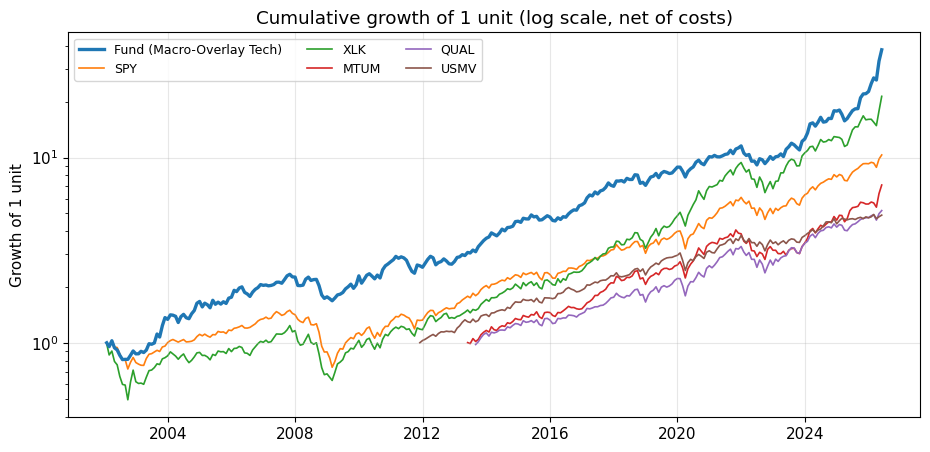

In [4]:
def to_series(points):
    idx = pd.to_datetime([p[0] for p in points])
    return pd.Series([p[1] for p in points], index=idx)

plt.figure()
for name, pts in GSD2T["equity_curves"].items():
    s = to_series(pts)
    lw, z = (2.4, 5) if "Fund" in name else (1.2, 1)
    plt.plot(s.index, s.values, label=name, linewidth=lw, zorder=z)
plt.yscale("log")
plt.title("Cumulative growth of 1 unit (log scale, net of costs)")
plt.ylabel("Growth of 1 unit"); plt.legend(ncol=3, fontsize=9)
plt.show()

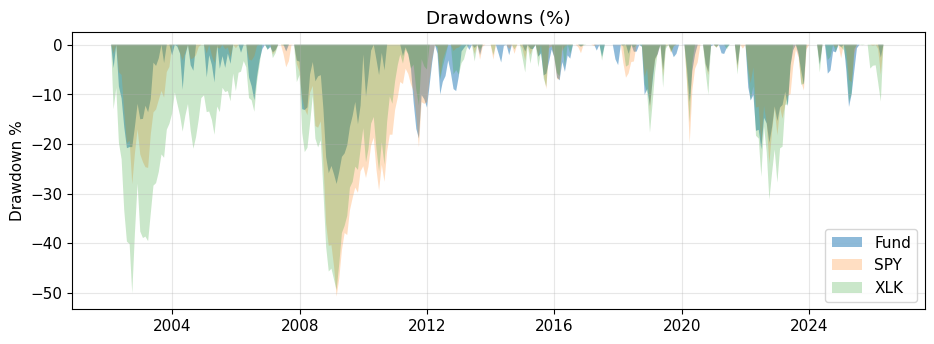

In [5]:
plt.figure(figsize=(11, 3.6))
for name, pts in GSD2T["drawdowns"].items():
    s = to_series(pts)
    plt.fill_between(s.index, s.values*100, 0, alpha=0.25 if name != "Fund" else 0.5,
                     label=name)
plt.title("Drawdowns (%)"); plt.ylabel("Drawdown %"); plt.legend()
plt.show()

## 3 · The six research iterations

We did not arrive at S1 by luck. Six strategies were tested on the **same universe and
window**. We pitch S1 but disclose every iteration — including the failures — for
research transparency.

In [6]:
rows = []
for key in ["S1", "S2c"]:
    v = FULL["contenders"][key]
    status = "PITCHED" if key == "S1" else "Viable alt"
    rows.append((f"{key} — {v['name']}", status, v["metrics"]))
for key in ["S2", "S2a", "S2b", "S3"]:
    v = FULL["rejected"][key]
    rows.append((f"{key} — {v['name']}", "Rejected", v["metrics"]))
for b in FULL["benchmark_metrics"]:
    rows.append((b["name"], "Benchmark", b))

raw, disp = metrics_frame(rows)
disp[["Status", "CAGR", "Sharpe", "MaxDD", "Calmar"]]

,Status,CAGR,Sharpe,MaxDD,Calmar
Strategy,,,,,
S1 — S1: Macro-Overlay Tech (pure momentum),PITCHED,16.1%,0.93,-28.1%,0.57
S2c — S2c: Multi-Factor + Macro Overlay,Viable alt,12.9%,0.95,-27.1%,0.48
S2 — S2: 3-factor L/S (original),Rejected,-12.6%,-0.49,-97.5%,-0.13
S2a — S2a: 2-factor L/S,Rejected,-12.1%,-0.37,-98.2%,-0.12
S2b — S2b: 2-factor long-only (no overlay),Rejected,18.8%,0.92,-49.5%,0.38
S3 — S3: Tech + VIX L/S,Rejected,4.9%,0.39,-41.7%,0.12
SPY,Benchmark,10.0%,0.71,-50.8%,0.20
XLK,Benchmark,13.4%,0.72,-50.2%,0.27
MTUM,Benchmark,16.2%,1.00,-30.7%,0.53


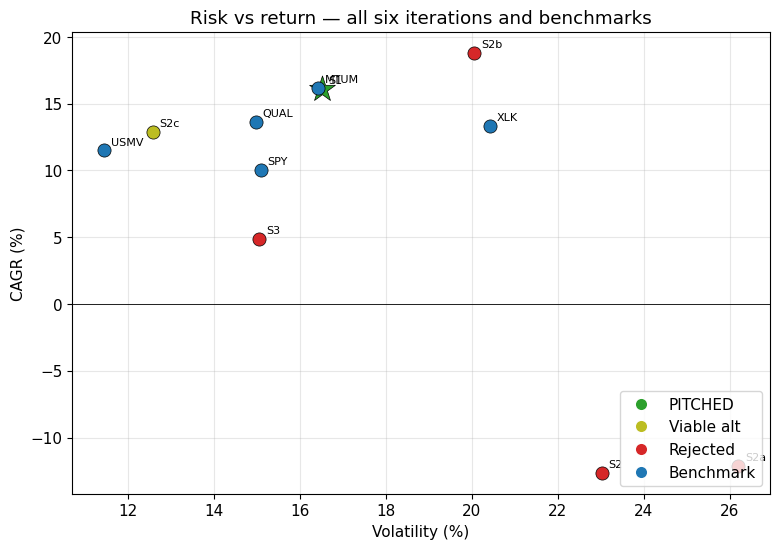

In [7]:
# Risk/return scatter of all iterations + benchmarks
fig, ax = plt.subplots(figsize=(9, 6))
colors = {"PITCHED": "tab:green", "Viable alt": "tab:olive",
          "Rejected": "tab:red", "Benchmark": "tab:blue"}
for label, r in raw.iterrows():
    c = colors.get(r["Status"], "gray")
    mk = "*" if r["Status"] == "PITCHED" else "o"
    sz = 380 if r["Status"] == "PITCHED" else 90
    ax.scatter(r["Vol"]*100, r["CAGR"]*100, c=c, marker=mk, s=sz,
               edgecolor="k", linewidth=0.5, zorder=3)
    ax.annotate(label.split(" — ")[0], (r["Vol"]*100, r["CAGR"]*100),
                fontsize=8, xytext=(5, 4), textcoords="offset points")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("Volatility (%)"); ax.set_ylabel("CAGR (%)")
ax.set_title("Risk vs return — all six iterations and benchmarks")
handles = [plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=v,
           label=k, markersize=9) for k, v in colors.items()]
ax.legend(handles=handles, loc="lower right")
plt.show()

## 4 · Why we rejected the long-short variants

The structural choice (long-only vs long-short) dominated the signal choice in this
universe. The 73-stock tech index is driven by 5–10 mega-caps; shorting any of them
through the 2018–2024 AI rally produced catastrophic drawdowns (-97% to -98%). Our
research learnings:

In [8]:
for L in FULL["research_learnings"]:
    print(f"• {L['title']}\n  {L['body']}\n")

• Reversal cancels momentum in composites
  Equal-weighting a 12-month momentum signal with a 1-month reversal signal yields a portfolio dominated by the low-vol residual. Either factor alone outperforms the naive composite. Lesson: factor combination requires thought about signal correlation, not just stacking premia.

• L/S in concentrated single-sector universes is broken
  Tech has winner-take-all dynamics: 5-10 mega-caps drive most of the index's returns. Shorting 14-18 names in this universe creates unhedged tail risk. The 2018-2024 factor crash is well-documented and our results are consistent with the AQR / Two Sigma underperformance period.

• Long-only + regime overlay > L/S in tech
  Both S1 and S2c (long-only + macro overlay variants) deliver Sharpe ~0.93-0.95. None of the L/S variants achieved positive Sharpe. The structural choice (long-only vs L/S) dominates the signal choice (momentum vs multi-factor).

• Macro overlay does what it says
  Comparing S2b vs S2c: the macro

## 5 · Backtest hygiene

The rubric rewards methodology, not just returns. Here are the checks that back the S1 pitch.

**5.1 · Factor regression (Fama-French 5 + Momentum, Newey-West SEs)**

In [9]:
fr = GSD2T["factor_regression"]
print(f"Annualised alpha : {fr['alpha_annualized']*100:.2f}%  "
      f"(t = {fr['alpha_tstat']:.2f})")
print(f"R-squared        : {fr['rsquared']:.3f}\n")
betas = pd.DataFrame({"beta": fr["betas"], "t-stat": fr["betas_tstat"]})
betas.round(3)

Annualised alpha : 5.79%  (t = 3.08)
R-squared        : 0.695



,beta,t-stat
Mkt-RF,0.753,15.451
SMB,0.210,2.753
HML,-0.085,-0.976
RMW,-0.447,-4.945
CMA,-0.235,-1.673
Mom,0.244,4.626


Alpha of **+5.79% (t = 3.08)** survives a full FF5+MOM factor model — the returns
are not just repackaged factor exposure. The negative RMW/CMA loadings are the
expected signature of a high-growth tech book.

**5.2 · Deflated Sharpe & capacity**

In [10]:
ds = GSD2T["deflated_sharpe"]; cap = GSD2T["capacity"]
print("Deflated Sharpe Ratio")
print(f"  observed SR    : {ds['observed_sr']:.2f}")
print(f"  threshold (n={ds['n_trials']}) : {ds['threshold_sr']:.2f}")
print(f"  PSR            : {ds['psr']:.3f}\n")
print("Capacity")
print(f"  avg holdings        : {cap['avg_n_holdings']:.1f}")
print(f"  avg annual turnover : {cap['avg_annual_turnover']*100:.0f}%")
print(f"  implied soft AUM cap: ${cap['implied_soft_aum_cap']/1e9:.2f}B "
      f"({cap['headroom_at_100m']:.1f}x headroom at $100M)")

Deflated Sharpe Ratio
  observed SR    : 0.80
  threshold (n=15) : 1.77
  PSR            : 0.000

Capacity
  avg holdings        : 15.5
  avg annual turnover : 375%
  implied soft AUM cap: $0.46B (4.6x headroom at $100M)


**5.3 · Parameter sensitivity** — Sharpe across lookback × quartile grid

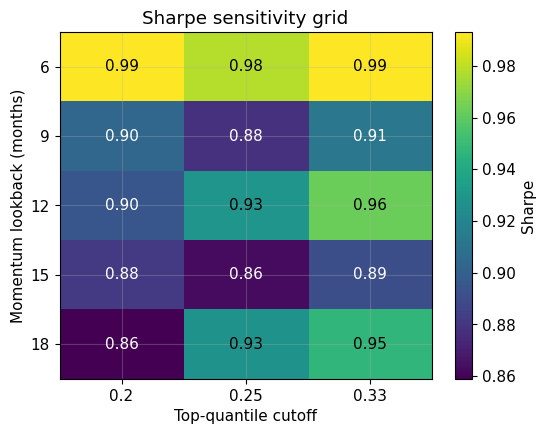

Sharpe range across 15 parameter settings: 0.86 – 0.99 (mean 0.92) — no single lucky cell.


In [11]:
sen = GSD2T["sensitivity"]
grid = np.array(sen["sharpe_grid"])
fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(grid, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(sen["quantiles"]))); ax.set_xticklabels(sen["quantiles"])
ax.set_yticks(range(len(sen["lookbacks"]))); ax.set_yticklabels(sen["lookbacks"])
ax.set_xlabel("Top-quantile cutoff"); ax.set_ylabel("Momentum lookback (months)")
ax.set_title("Sharpe sensitivity grid")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax.text(j, i, f"{grid[i,j]:.2f}", ha="center", va="center",
                color="w" if grid[i,j] < grid.mean() else "k")
fig.colorbar(im, label="Sharpe")
plt.show()
print(f"Sharpe range across {grid.size} parameter settings: "
      f"{sen['min_sharpe']:.2f} – {sen['max_sharpe']:.2f} "
      f"(mean {sen['mean_sharpe']:.2f}) — no single lucky cell.")

**5.4 · Stress scenarios** — total return through seven named crises

In [12]:
st = pd.DataFrame(GSD2T["stress_tests"])
disp = st[["window", "fund_total", "spy_total", "xlk_total", "fund_dd"]].copy()
for c in ["fund_total", "spy_total", "xlk_total", "fund_dd"]:
    disp[c] = disp[c].map(as_pct)
disp.columns = ["Crisis window", "Fund total", "SPY total", "XLK total", "Fund max-DD"]
disp

,Crisis window,Fund total,SPY total,XLK total,Fund max-DD
0,Dot-com (2000-09 → 2002-10),-14.3%,-40.2%,-73.9%,-20.9%
1,GFC (2007-10 → 2009-02),-26.7%,-49.9%,-46.7%,-28.1%
2,Eurozone (2011-07 → 2011-09),-14.9%,-13.8%,-7.8%,-8.3%
3,China (2015-08 → 2016-02),-5.5%,-7.0%,-2.9%,-6.3%
4,Vol spike (2018-10 → 2018-12),-12.0%,-13.6%,-17.4%,-3.7%
5,COVID (2020-02 → 2020-04),-5.2%,-9.2%,-3.6%,-7.0%
6,2022 bear (2021-12 → 2022-09),-17.8%,-20.7%,-29.2%,-21.1%


## 6 · Known limitation — survivorship bias (and how we plan to address it)

Our universe is the **current** S&P 500 Information Technology constituents, not the
point-in-time membership. This is survivorship-biased and we disclose it.

**Mitigating context:** the bias is modest here — this is a *large-cap* universe where
names rarely vanish without warning, and most exits are mergers (whose returns we would
capture). Survivorship bias in large-caps is far smaller than in small-caps.

**Planned fixes (v2):**
1. **Point-in-time membership** from CRSP (via WRDS) or Bloomberg `INDX_MWEIGHT_HIST`,
   incl. delisted names with delisting returns — the proper fix.
2. **Survivorship haircut / sensitivity:** subtract a 1–3%/yr penalty and show the
   strategy still clears its benchmarks.
3. **ETF-level robustness check:** the same macro overlay on XLK/MTUM (which are
   survivorship-free indices by construction).

---
### Disclaimer
This is a **fictional pitch** for the ESADE Asset Management course. It is not investment
advice. The fund "GSD2T Asset Management" does not exist. All performance is **simulated**
on historical data; past performance — simulated or otherwise — does not indicate future
results. Universe is biased to current S&P 500 constituents; survivorship bias is
disclosed and not yet corrected.